<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day9_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training ",X_train.shape)
print("Testing : ",X_test.shape)

Training  (455, 30)
Testing :  (114, 30)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn= KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [11]:
y_pred = knn.predict(X_test_scaled)

print(y_pred[:20])

[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [12]:
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = knn.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:",accuracy)
print("Precision",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("ROC AUC Score:",roc_auc)

Accuracy: 0.956140350877193
Precision 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
ROC AUC Score: 0.9788359788359788


In [17]:
k_values = range(1,21)

accuracies = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)

  predictions =  knn.predict(X_test_scaled)
  accuracy = accuracy_score(y_test, predictions)
  accuracies.append(accuracy)

print(accuracies)

[0.9385964912280702, 0.9298245614035088, 0.9824561403508771, 0.9473684210526315, 0.956140350877193, 0.956140350877193, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9649122807017544, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9649122807017544, 0.9736842105263158, 0.9736842105263158, 0.9824561403508771, 0.9824561403508771, 0.9736842105263158, 0.9736842105263158]


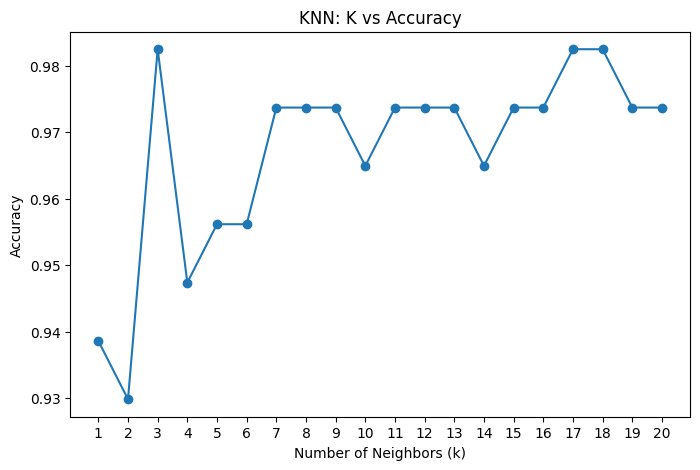

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")

plt.xticks(list(k_values))
plt.show()

In [19]:
best_k = 17

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled,y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:1]

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Re-calculate knn_prob to correct the inconsistent sample issue
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_prob)

print("KNN Results")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)
print("ROC-AUC  :", knn_auc)

KNN Results
Accuracy : 0.9824561403508771
Precision: 0.972972972972973
Recall   : 1.0
F1 Score : 0.9863013698630136
ROC-AUC  : 0.9928902116402116


In [22]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','KNN'],
    'Accuracy':[accuracy,knn_accuracy],
    'Precision':[precision,knn_precision],
    'Recall':[recall,knn_recall],
    'F! Score':[f1,knn_f1],
    'ROC_AUC':[roc_auc,knn_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F! Score,ROC_AUC
0,Logistic Regression,0.973684,0.958904,0.972222,0.965517,0.978836
1,KNN,0.982456,0.972973,1.000000,0.986301,0.992890


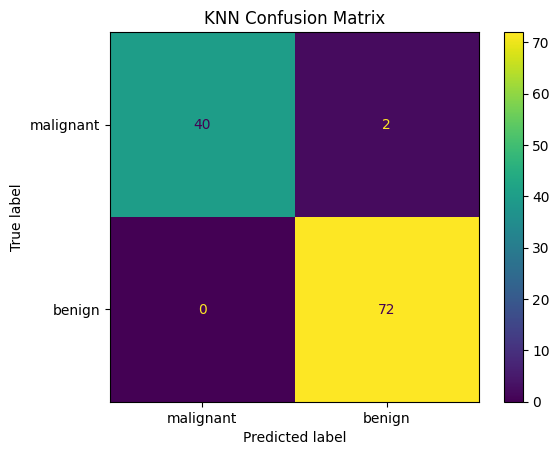

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred, display_labels=data.target_names
)

plt.title("KNN Confusion Matrix")
plt.show()

In [24]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [accuracy, knn_accuracy],
    'Precision': [precision, knn_precision],
    'Recall': [recall, knn_recall],
    'F1 Score': [f1, knn_f1],
    'ROC-AUC': [roc_auc, knn_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973684,0.958904,0.972222,0.965517,0.978836
1,KNN,0.982456,0.972973,1.000000,0.986301,0.992890
